In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [198]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [199]:
df.shape

(5110, 12)

In [200]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [201]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [202]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [203]:
df = df[df['gender']!='Other']

* `Data Set is Imbalance need to Balance it `

In [204]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

* `Only bmi column has 201 missing entries`

In [205]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,4908.00000,5109.000000
mean,36513.985516,43.229986,0.097475,0.054022,106.140399,28.89456,0.048738
std,21162.008804,22.613575,0.296633,0.226084,45.285004,7.85432,0.215340
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.30000,0.000000
25%,17740.000000,25.000000,0.000000,0.000000,77.240000,23.50000,0.000000
50%,36922.000000,45.000000,0.000000,0.000000,91.880000,28.10000,0.000000
75%,54643.000000,61.000000,0.000000,0.000000,114.090000,33.10000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.60000,1.000000


* `Age Columns has value 0.008 this can't be age need to correct it or remove it `

In [206]:
df['age'].min()

np.float64(0.08)

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5109 non-null   int64  
 1   gender             5109 non-null   object 
 2   age                5109 non-null   float64
 3   hypertension       5109 non-null   int64  
 4   heart_disease      5109 non-null   int64  
 5   ever_married       5109 non-null   object 
 6   work_type          5109 non-null   object 
 7   Residence_type     5109 non-null   object 
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                4908 non-null   float64
 10  smoking_status     5109 non-null   object 
 11  stroke             5109 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 518.9+ KB


* `Need to change the type of Age  from float to Int`

In [208]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [209]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [210]:
df['ever_married'].unique()

array(['Yes', 'No'], dtype=object)

In [211]:
df['work_type'].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [212]:
df['Residence_type'].unique()

array(['Urban', 'Rural'], dtype=object)

In [213]:
df['smoking_status'].unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

### **EDA**

<Axes: xlabel='age', ylabel='Density'>

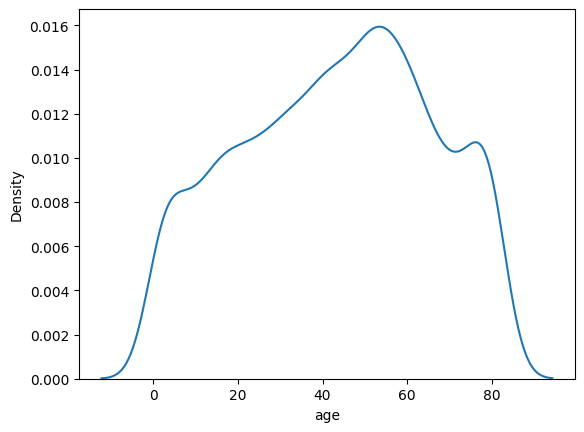

In [214]:
## plot of age to check the distribution
sns.kdeplot(x='age',data=df)

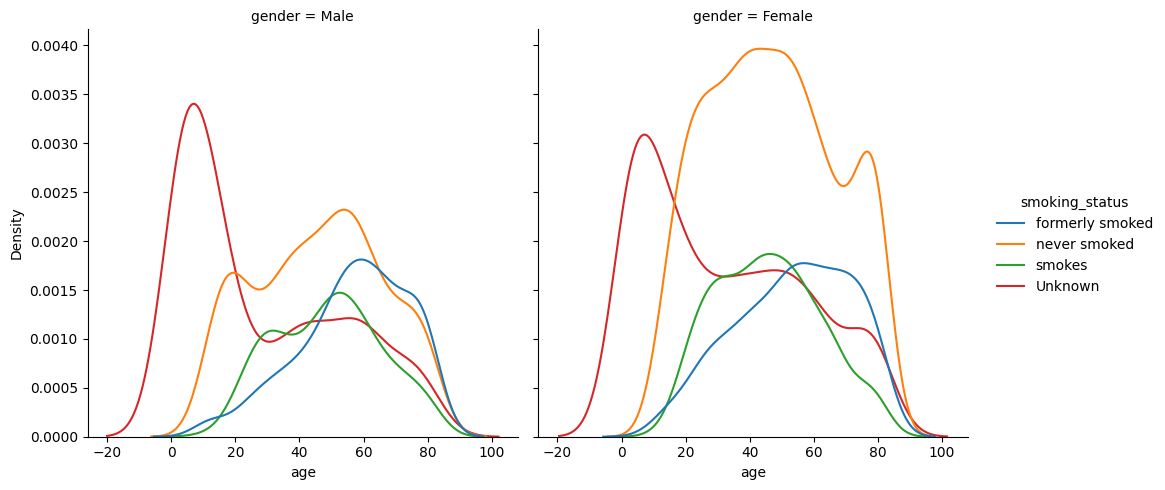

In [215]:
sns.displot(data=df,x='age',hue='smoking_status',col='gender',kind='kde')


In [216]:
df.sample()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4156,37728,Female,26.0,0,0,Yes,Private,Urban,68.99,22.2,never smoked,0


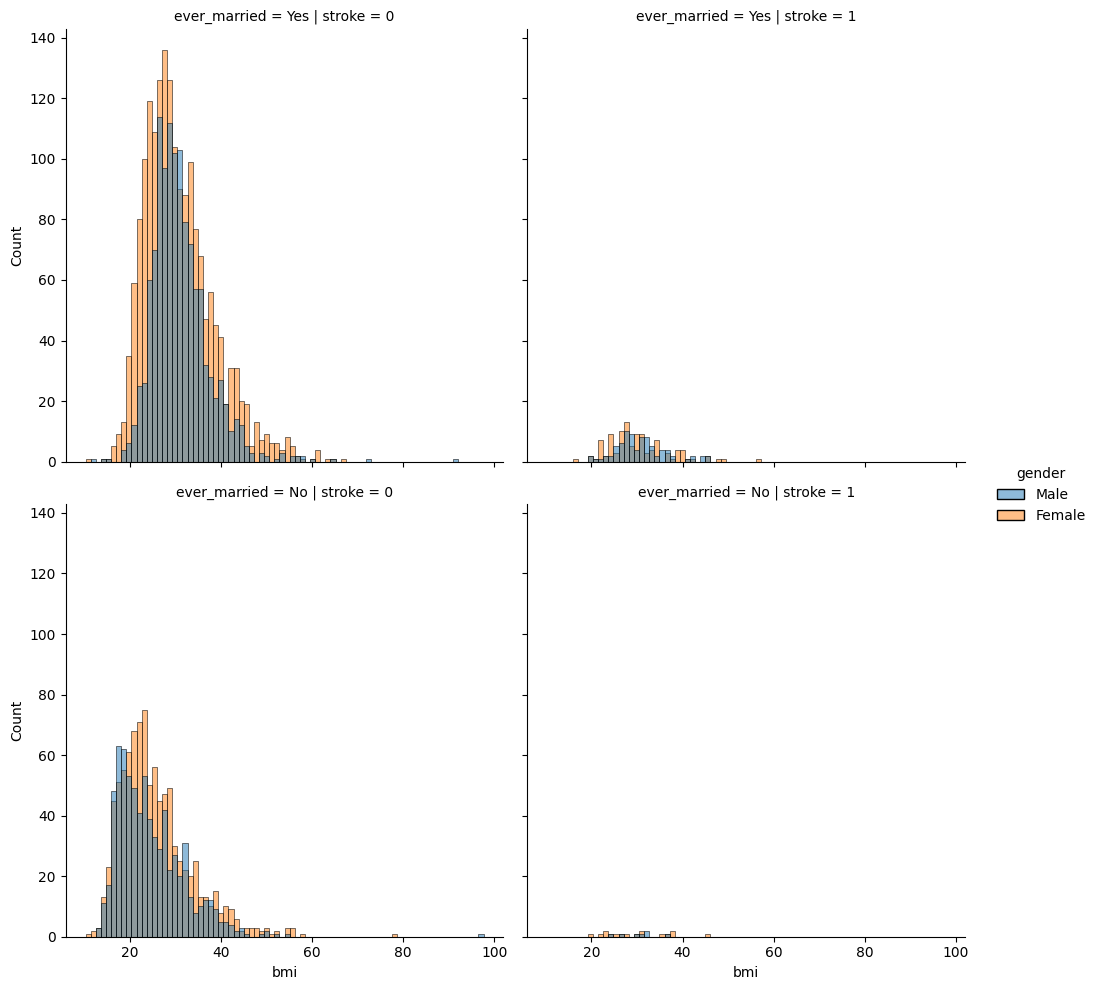

In [217]:
sns.displot(data=df,x='bmi',hue='gender',col='stroke',row='ever_married')

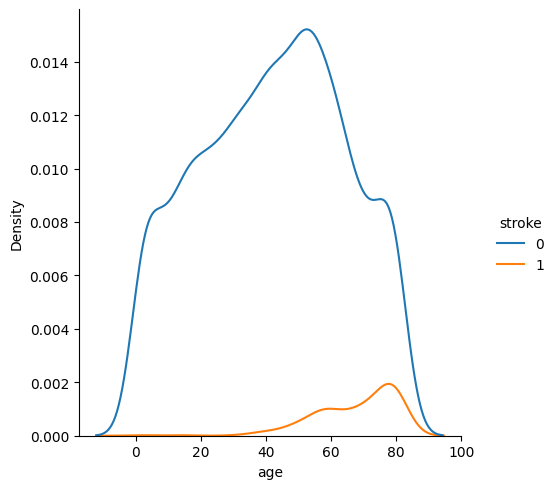

In [218]:
sns.displot(data=df,x='age',hue='stroke',kind='kde')

* `This graph show that as the age increases the stroke in people also increase`

In [219]:
import warnings 
warnings.filterwarnings('ignore')

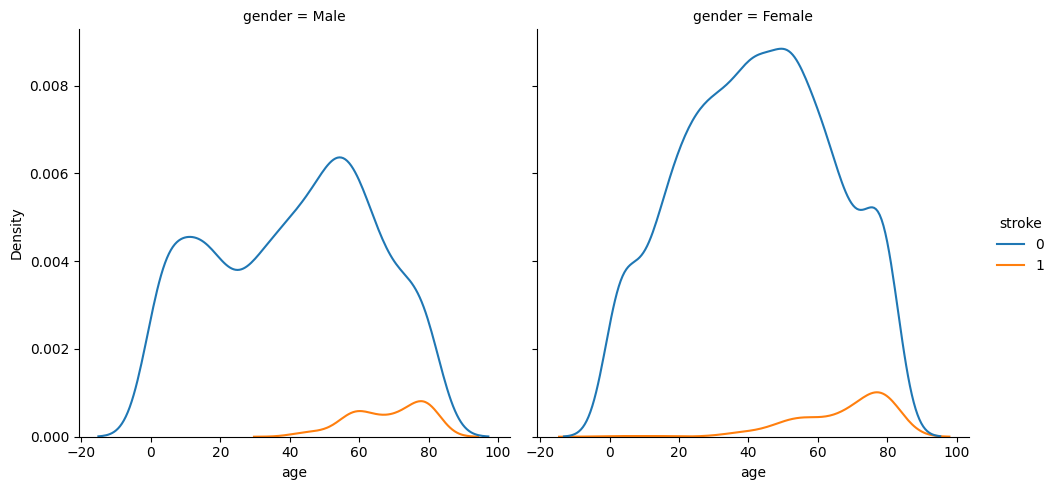

In [220]:
sns.displot(data=df,x='age',hue='stroke',kind='kde',col='gender')

* `No matter whether a person is female or male as age increases the chance of stroke also increases`

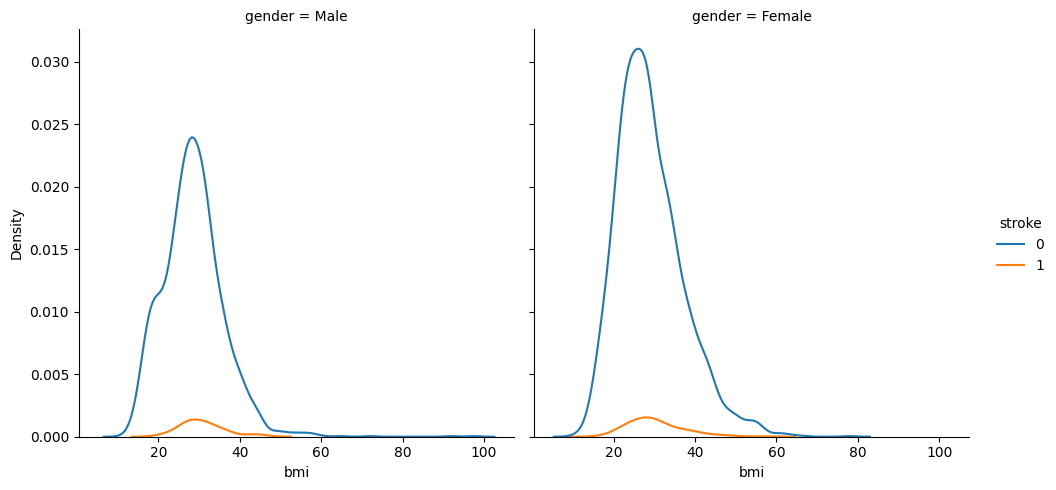

In [221]:
sns.displot(data=df,x='bmi',hue='stroke',kind='kde',col='gender')

* `Strok attack those people whose bmi are b/w 20 to 40`

In [222]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


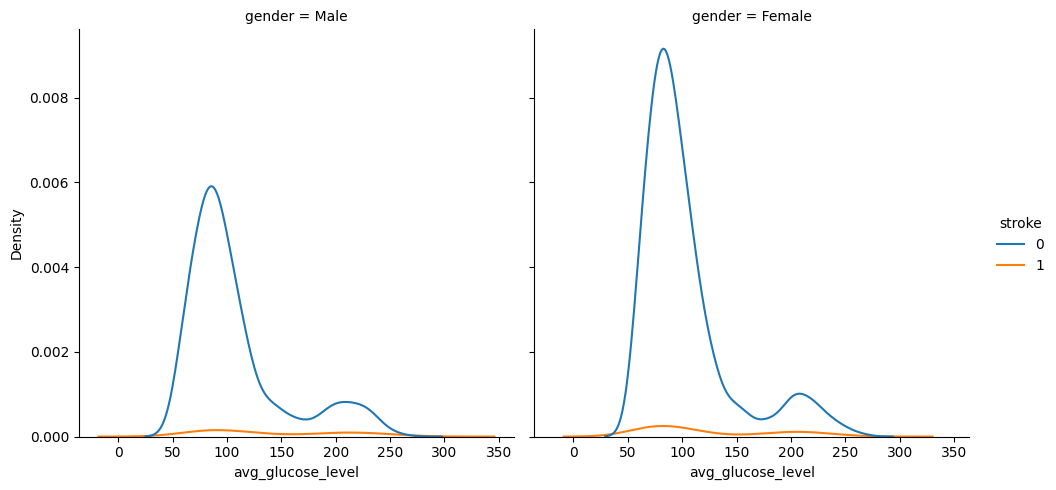

In [223]:
sns.displot(data=df,x='avg_glucose_level',hue='stroke',kind='kde',col='gender')

In [224]:
df[df['gender']=='Other']

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


* `I have only one person whose gender is other need to manage this also`

In [225]:
objects = [col for col in df.columns if df[col].dtype =='O']
numeric = [col for col in df.columns if df[col].dtype !='O']

In [226]:
print('Categorical Columns:\n',objects)

Categorical Columns:
 ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [227]:
print('Numerical Columns:\n',numeric)

Numerical Columns:
 ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']


In [228]:
df[objects]

,gender,ever_married,work_type,Residence_type,smoking_status
0,Male,Yes,Private,Urban,formerly smoked
1,Female,Yes,Self-employed,Rural,never smoked
2,Male,Yes,Private,Rural,never smoked
3,Female,Yes,Private,Urban,smokes
4,Female,Yes,Self-employed,Rural,never smoked
...,...,...,...,...,...
5105,Female,Yes,Private,Urban,never smoked
5106,Female,Yes,Self-employed,Urban,never smoked
5107,Female,Yes,Self-employed,Rural,never smoked
5108,Male,Yes,Private,Rural,formerly smoked


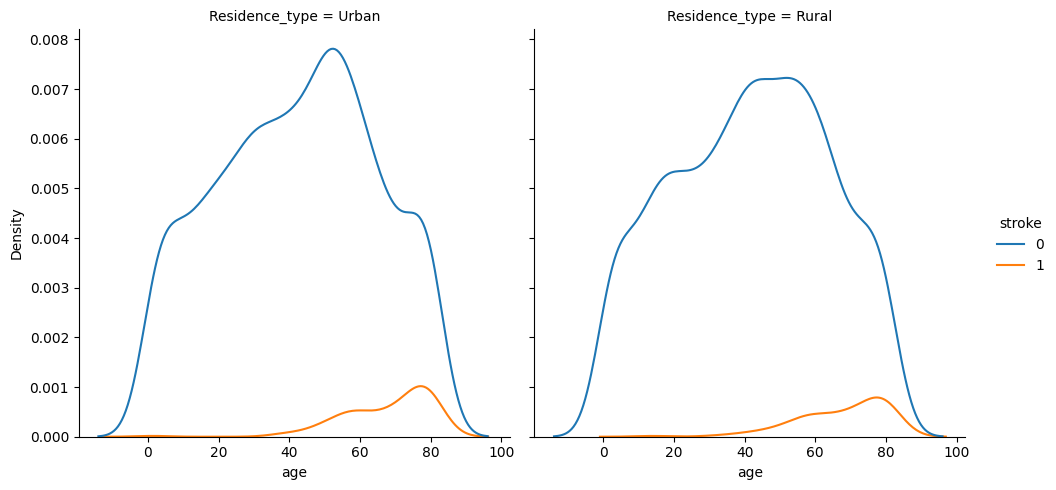

In [229]:
sns.displot(data=df,x='age',hue='stroke',kind='kde',col='Residence_type')

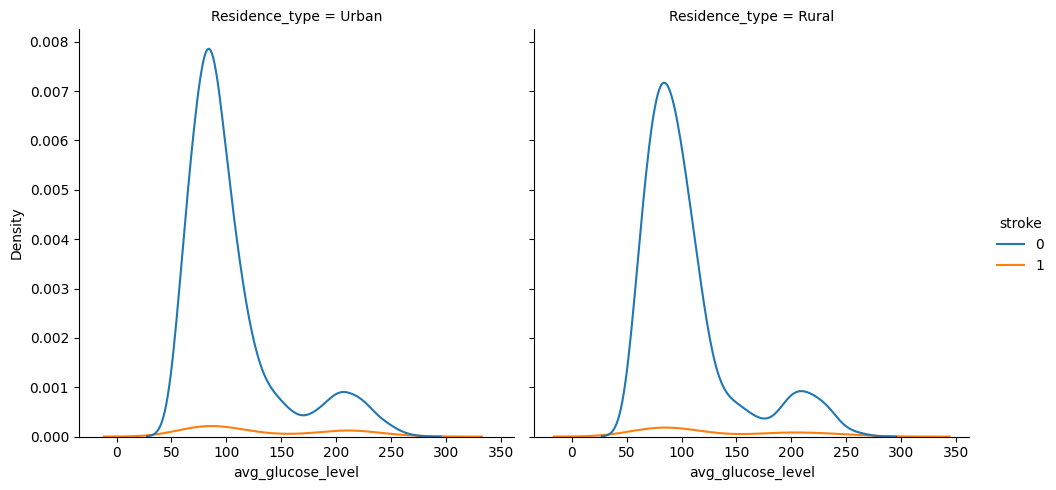

In [230]:
sns.displot(data=df,x='avg_glucose_level',hue='stroke',kind='kde',col='Residence_type')

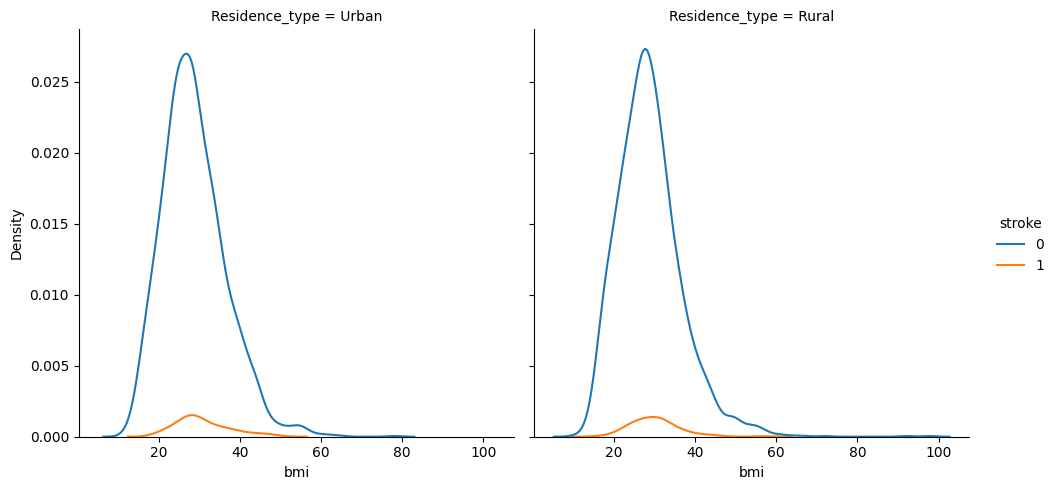

In [231]:
sns.displot(data=df,x='bmi',hue='stroke',kind='kde',col='Residence_type')

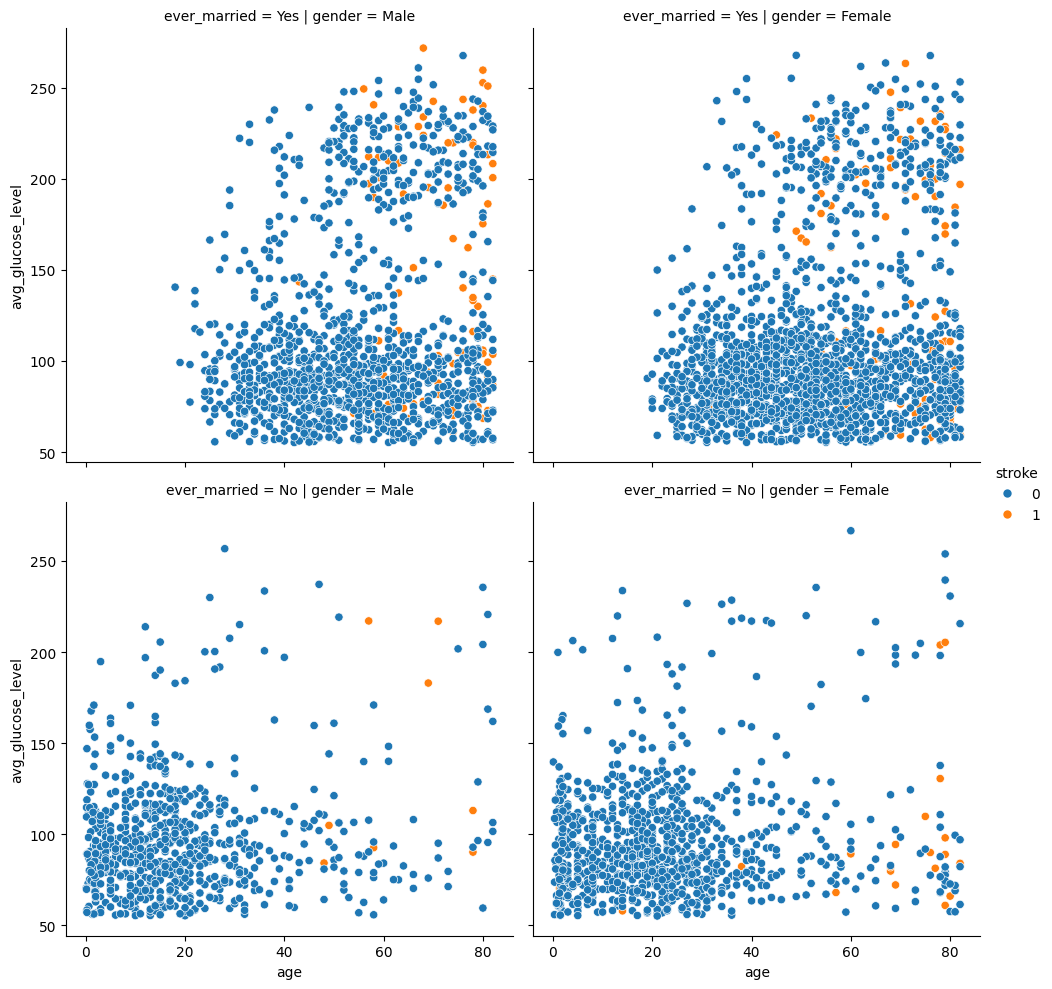

In [232]:
sns.relplot(data=df,x='age',y='avg_glucose_level',hue='stroke',col='gender',row='ever_married')

In [233]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


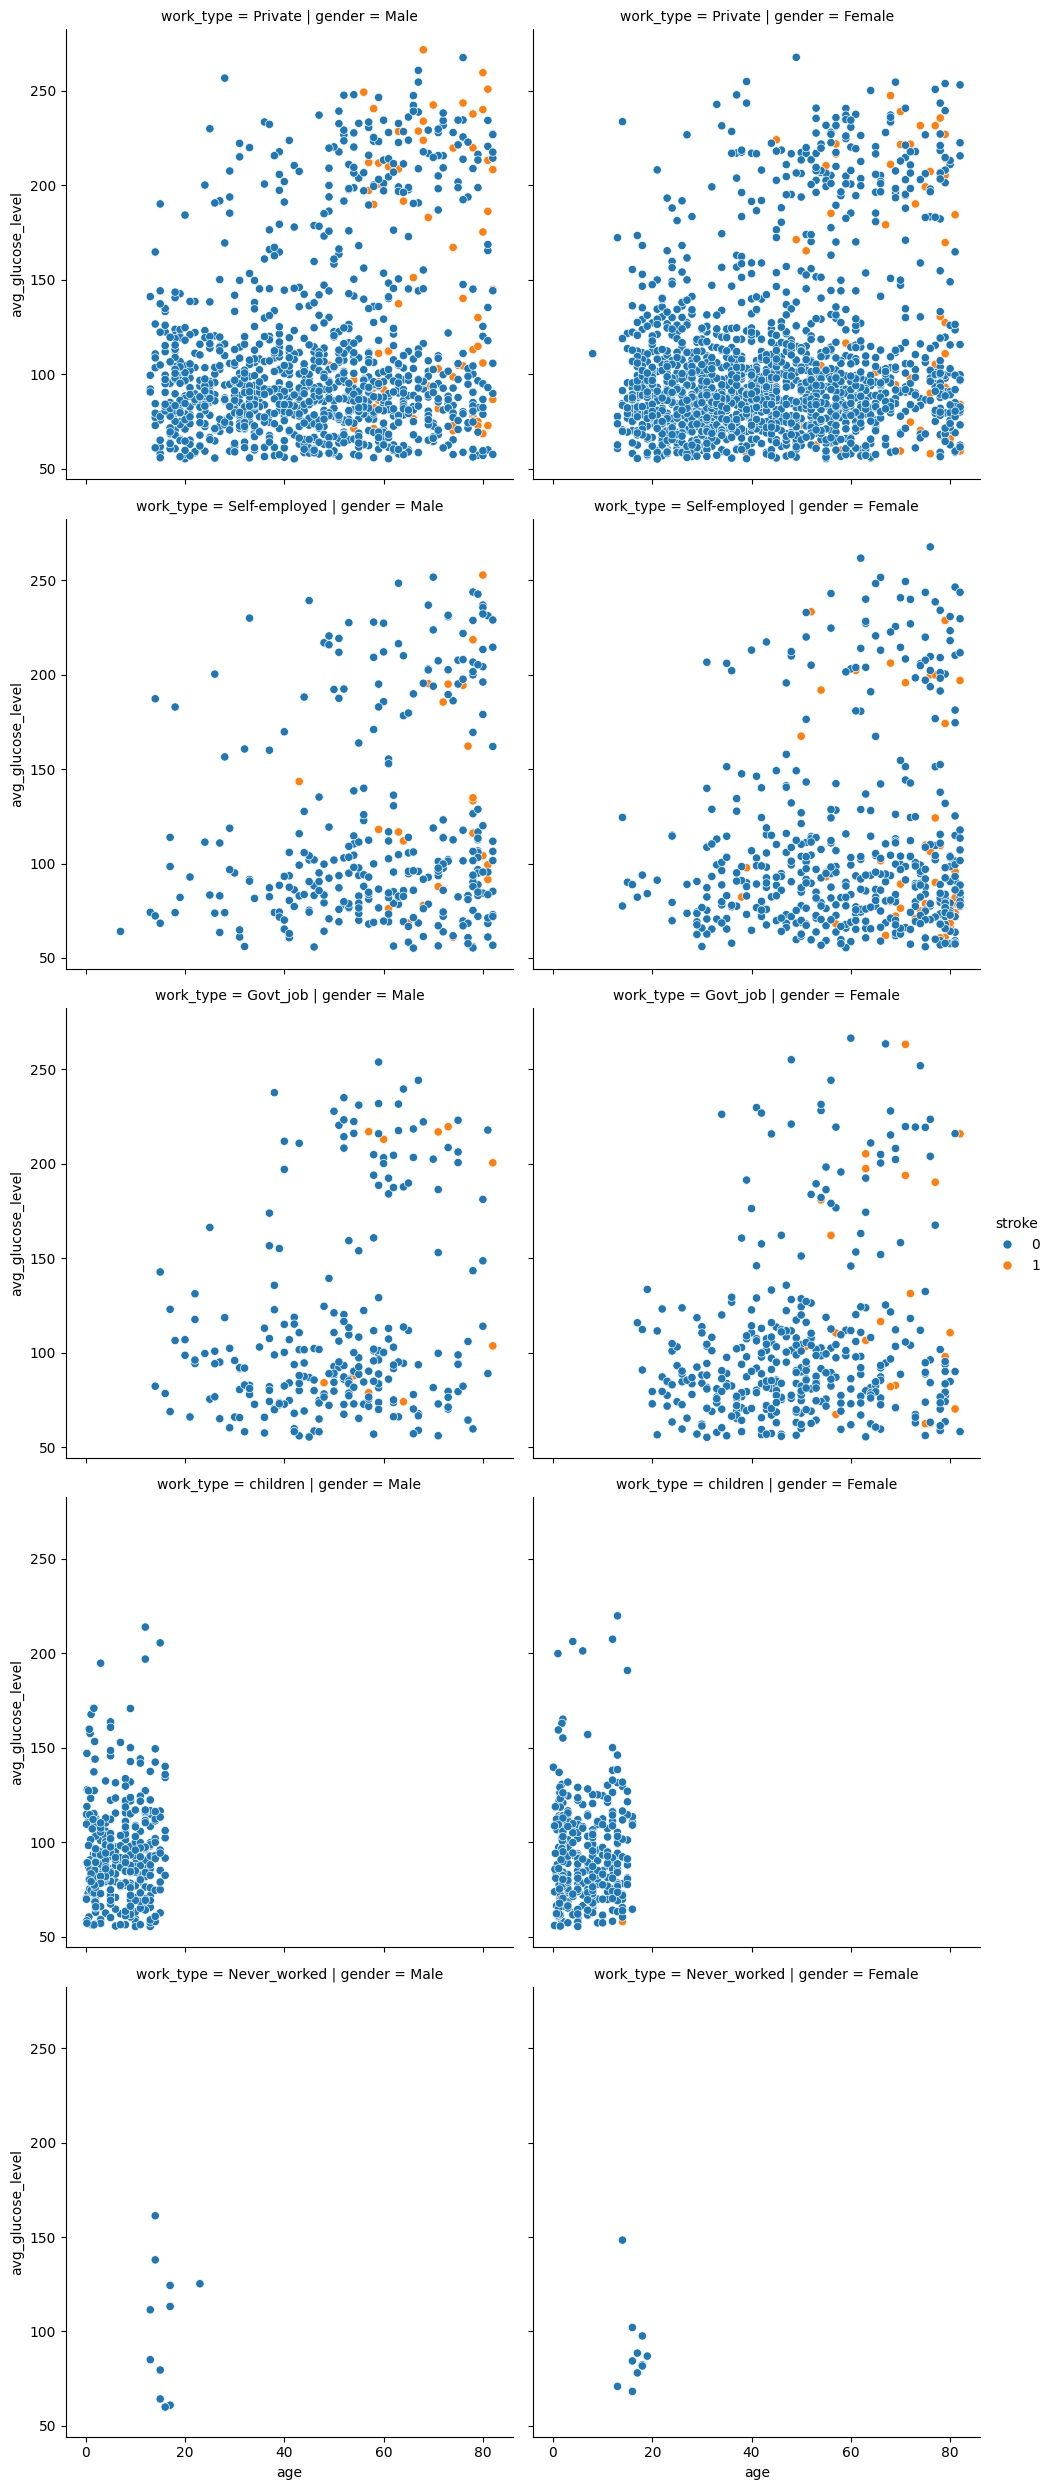

In [234]:
sns.relplot(data=df,x='age',y='avg_glucose_level',hue='stroke',col='gender',row='work_type')

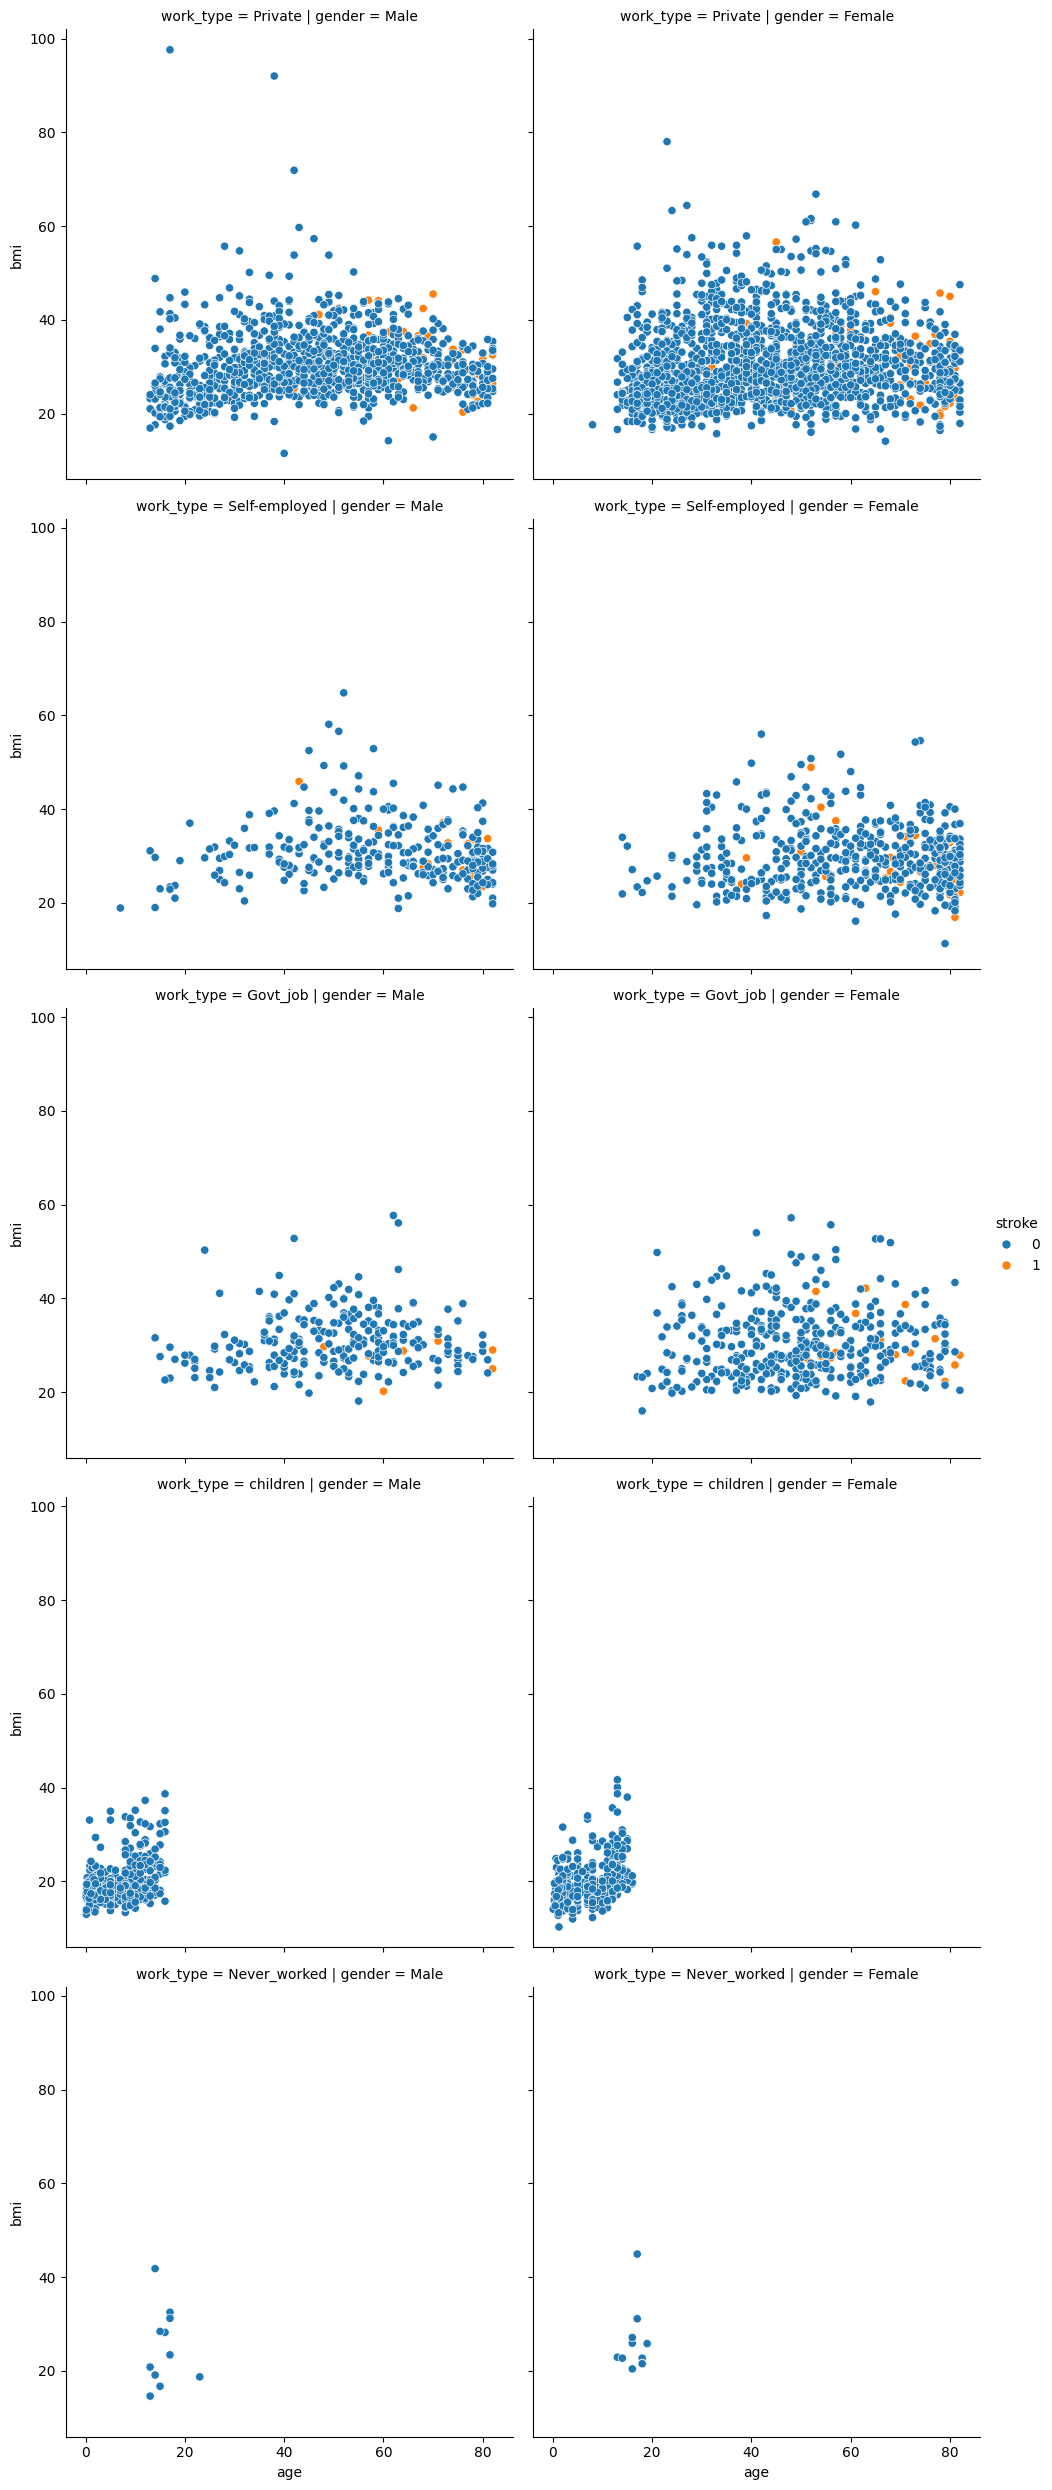

In [235]:
sns.relplot(data=df,x='age',y='bmi',hue='stroke',col='gender',row='work_type')

In [236]:
pd.crosstab(index=df['gender'],columns=df['stroke'],values=df['age'],aggfunc='count')

stroke,0,1
gender,,
Female,2853,141
Male,2007,108


In [237]:
pd.pivot_table(df,columns='smoking_status',index=['stroke','gender'],values='age',aggfunc='count')

smoking_status  Unknown  formerly smoked  never smoked  smokes
stroke gender                                                 
0      Female       811              443          1166     433
       Male         686              371           636     314
1      Female        25               34            63      19
       Male          22               36            27      23

In [238]:
pd.crosstab(columns=df['smoking_status'],index=df['stroke'],values=df['age'],aggfunc='count')

smoking_status,Unknown,formerly smoked,never smoked,smokes
stroke,,,,
0,1497,814,1802,747
1,47,70,90,42


In [239]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [240]:
pd.pivot_table(df,columns='smoking_status',index=['stroke','heart_disease','gender'],values='age',aggfunc='count')

smoking_status               Unknown  formerly smoked  never smoked  smokes
stroke heart_disease gender                                                
0      0             Female      796              421          1131     411
                     Male        661              328           593     290
       1             Female       15               22            35      22
                     Male         25               43            43      24
1      0             Female       22               29            56      15
                     Male         17               29            22      12
       1             Female        3                5             7       4
                     Male          5                7             5      11

## **Now we check Outliers**

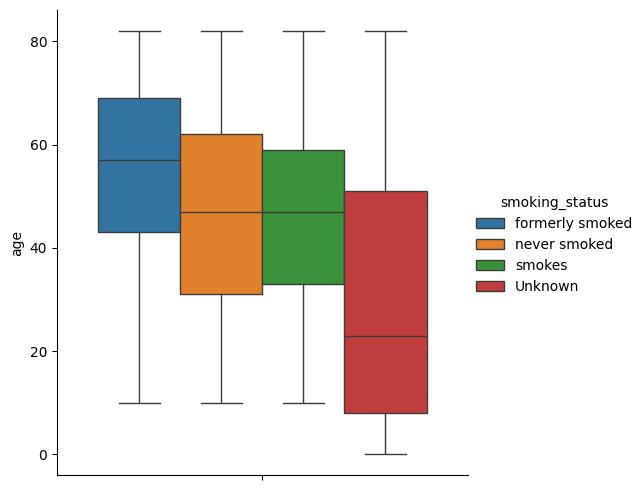

In [241]:
sns.catplot(data=df,y='age',hue='smoking_status',kind='box')

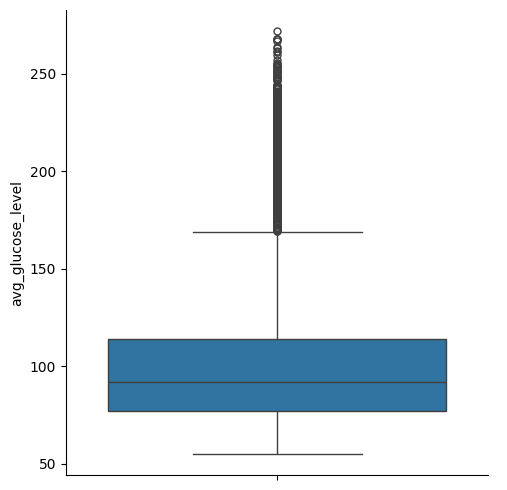

In [242]:
sns.catplot(data=df,y='avg_glucose_level',kind='box')

* `Outliers in glucose level columns`

In [243]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


### **Data Cleaning**

In [244]:
df[df['bmi'].isnull()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5039,42007,Male,41.0,0,0,No,Private,Rural,70.15,NaN,formerly smoked,0
5048,28788,Male,40.0,0,0,Yes,Private,Urban,191.15,NaN,smokes,0
5093,32235,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,NaN,smokes,0
5099,7293,Male,40.0,0,0,Yes,Private,Rural,83.94,NaN,smokes,0


In [245]:
df['bmi'].describe()

count    4908.00000
mean       28.89456
std         7.85432
min        10.30000
25%        23.50000
50%        28.10000
75%        33.10000
max        97.60000
Name: bmi, dtype: float64

In [246]:
df['bmi'].value_counts()

bmi
28.7    41
28.4    38
27.7    37
27.6    37
26.7    37
        ..
47.9     1
13.0     1
13.9     1
54.1     1
14.9     1
Name: count, Length: 418, dtype: int64

In [247]:
df[['gender','bmi']].value_counts().head(50)

gender  bmi 
Female  23.4    25
        28.4    24
        26.4    24
        22.7    23
Male    26.7    23
Female  24.8    23
        26.1    23
        27.6    21
        25.5    21
Male    27.3    21
Female  28.7    21
        22.2    21
        24.9    21
        22.8    20
        24.5    20
Male    28.7    20
Female  24.2    20
        26.6    20
        27.1    20
        29.1    20
Male    26.5    19
Female  27.0    19
        27.7    19
        26.9    19
        28.1    19
        21.5    19
        29.9    18
        29.7    18
        25.1    18
        25.4    18
        22.1    18
Male    27.7    18
Female  27.5    18
        28.3    18
        23.0    18
        24.1    18
        24.0    17
Male    29.4    17
Female  27.9    17
        21.3    17
        19.5    17
        23.1    17
        21.4    17
Male    30.3    16
Female  28.9    16
        28.8    16
Male    31.9    16
        25.1    16
        23.5    16
        27.6    16
Name: count, dtype: int64

In [248]:
df[df['bmi'].isnull()]['stroke'].value_counts()

stroke
0    161
1     40
Name: count, dtype: int64

<Axes: >

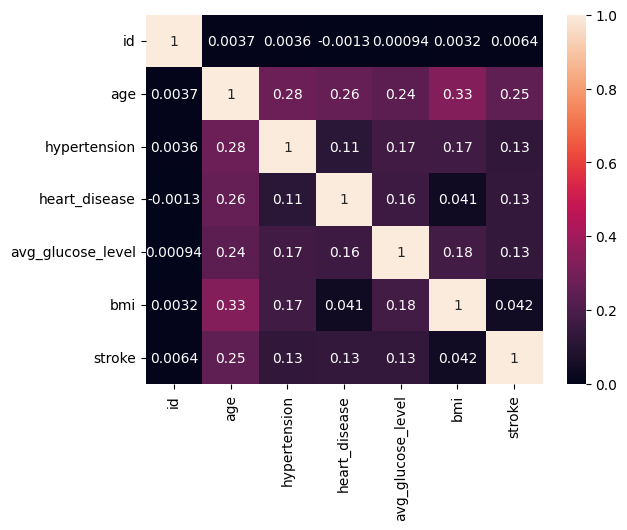

In [249]:
sns.heatmap(df[numeric].corr(),annot=True)

In [250]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


<Axes: xlabel='bmi', ylabel='Count'>

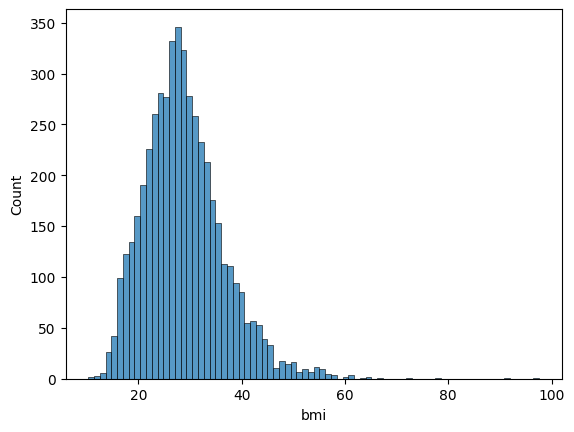

In [251]:
sns.histplot(data=df,x='bmi')

In [252]:
df[df['bmi']>60]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
270,72911,Female,57.0,1,0,Yes,Private,Rural,129.54,60.9,smokes,0
358,66333,Male,52.0,0,0,Yes,Self-employed,Urban,78.40,64.8,never smoked,0
466,1307,Female,61.0,1,0,Yes,Private,Rural,170.05,60.2,smokes,0
544,545,Male,42.0,0,0,Yes,Private,Rural,210.48,71.9,never smoked,0
928,41097,Female,23.0,1,0,No,Private,Urban,70.03,78.0,smokes,0
1559,37759,Female,53.0,0,0,Yes,Private,Rural,72.63,66.8,Unknown,0
2128,56420,Male,17.0,1,0,No,Private,Rural,61.67,97.6,Unknown,0
2764,20292,Female,24.0,0,0,Yes,Private,Urban,85.55,63.3,never smoked,0
2840,65895,Female,52.0,0,0,Yes,Private,Urban,98.27,61.2,Unknown,0
3825,72784,Female,52.0,0,0,Yes,Private,Rural,118.46,61.6,smokes,0


In [253]:
for col in objects:
    df[col].value_counts().iloc[0,0]
    break

IndexingError: Too many indexers

In [254]:
df.groupby('smoking_status')['bmi'].median()

smoking_status
Unknown            24.30
formerly smoked    29.85
never smoked       28.60
smokes             29.10
Name: bmi, dtype: float64

In [255]:
df.groupby('work_type')['bmi'].median().to_dict()

{'Govt_job': 29.4,
 'Never_worked': 23.15,
 'Private': 28.95,
 'Self-employed': 29.4,
 'children': 18.9}

In [256]:
df['work_type'].value_counts()

work_type
Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [257]:
df.groupby(['stroke','smoking_status','work_type'])['bmi'].median().reset_index()

,stroke,smoking_status,work_type,bmi
0,0,Unknown,Govt_job,28.90
1,0,Unknown,Never_worked,21.15
2,0,Unknown,Private,28.35
3,0,Unknown,Self-employed,29.30
4,0,Unknown,children,18.70
5,0,formerly smoked,Govt_job,30.40
6,0,formerly smoked,Private,29.80
7,0,formerly smoked,Self-employed,30.00
8,0,formerly smoked,children,20.40
9,0,never smoked,Govt_job,29.00


In [258]:
df.groupby('work_type')['bmi'].count()

work_type
Govt_job          630
Never_worked       22
Private          2810
Self-employed     775
children          671
Name: bmi, dtype: int64

In [259]:
df['work_type'].value_counts()

work_type
Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [260]:
{'Govt_job': 29.4,
 'Never_worked': 23.15,
 'Private': 28.95,
 'Self-employed': 29.4,
 'children': 18.9}

{'Govt_job': 29.4,
 'Never_worked': 23.15,
 'Private': 28.95,
 'Self-employed': 29.4,
 'children': 18.9}

In [263]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [276]:
df['bmi'].median()

np.float64(28.1)

* `Filling missing value in bmi column`

In [280]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [283]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [321]:
df.reset_index(inplace=True)

#### **Encoding** 

In [322]:
objects

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

In [323]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

In [324]:
df[objects].columns.tolist()

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

In [325]:
encoded = encoder.fit_transform(df[['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']]).toarray()

In [326]:
encoded

array([[0., 1., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(5109, 15))

In [327]:
encoded_df = pd.DataFrame(encoded,columns = encoder.get_feature_names_out())

In [328]:
new_df = pd.concat([df,encoded_df],axis=1)

In [329]:
new_df

,index,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5104,5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5105,5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5106,5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5107,5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [330]:
encoded_df.isnull().sum()

gender_Female                     0
gender_Male                       0
ever_married_No                   0
ever_married_Yes                  0
work_type_Govt_job                0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Rural              0
Residence_type_Urban              0
smoking_status_Unknown            0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

In [331]:
df.isnull().sum()

index                0
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [332]:
encoded_df.shape,df.shape

((5109, 15), (5109, 13))

In [333]:
pd.concat([df,encoded_df],axis=1)

,index,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5104,5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5105,5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5106,5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5107,5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [336]:
new_df.drop(['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'],axis=1,inplace=True)

In [ ]:
new_df.drop('index',axis=1,inplace=True)
new_df.drop('id',axis=1,inplace=True)

In [341]:
new_df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,ever_married_No,ever_married_Yes,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,61.0,0,0,202.21,28.1,1,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,80.0,0,1,105.92,32.5,1,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,49.0,0,0,171.23,34.4,1,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,79.0,1,0,174.12,24.0,1,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### **Scaling**

In [342]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [345]:
new_df[['age','avg_glucose_level','bmi']] = scaler.fit_transform(df[['age','avg_glucose_level','bmi']])

In [346]:
new_df

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,ever_married_No,ever_married_Yes,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.051242,0,1,2.706450,1.004893,1,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.785889,0,0,2.121652,-0.099142,1,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.626174,0,1,-0.004867,0.472358,1,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.255182,0,0,1.437473,0.719142,1,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.581949,1,0,1.501297,-0.631677,1,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5104,1.626174,1,0,-0.494481,-0.099142,0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5105,1.670400,0,0,0.420922,1.446507,0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5106,-0.363976,0,0,-0.511266,0.225574,0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5107,0.343633,0,0,1.328375,-0.423859,0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [349]:
new_df['stroke'] = new_df['stroke'].astype(int)

### Now the Data is Ready to give it to Model

In [351]:
X = new_df.drop('stroke',axis=1)
y = new_df['stroke']

In [354]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

In [355]:
X_train.shape,y_train.shape

((4087, 20), (4087,))

In [358]:
from sklearn.linear_model import LogisticRegression

In [359]:
lr = LogisticRegression()
lr.fit(X_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [360]:
y_pred = lr.predict(X_test)

In [366]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report

In [367]:
print(accuracy_score(y_test,y_pred)) 
print(precision_score(y_test,y_pred)) 
print(recall_score(y_test,y_pred)) 
print(classification_report(y_test,y_pred))

0.952054794520548
1.0
0.02
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



In [388]:
y_pred[y_pred==1]

array([1])